## 1. Setup & Import Library

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_curve,
    auc,
)

import matplotlib.pyplot as plt
import joblib
import gradio as gr

RANDOM_STATE = 42


e:\UNIVERSITAS MUHAMMADIYAH MAKASSAR\SEMESTER 5\APPLIED MACHINE LEARNING\TUGAS MID BESAR\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Data Understanding

In [3]:
CSV_PATH = r"Open-Meteo 2025 Makassar.csv"

header_row = None
with open(CSV_PATH, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if line.strip().startswith("time,"):
            header_row = i
            break

if header_row is None:
    raise ValueError("Tidak ditemukan baris header yang dimulai 'time,' di file CSV.")

print("Header data (time,...) ada di baris ke:", header_row)
df = pd.read_csv(CSV_PATH, skiprows=header_row)

print("===== NAMA KOLOM DATASET (MENTAH) =====")
print(df.columns)
print("Jumlah baris & kolom (data cuaca):", df.shape)
df.head()


Header data (time,...) ada di baris ke: 3
===== NAMA KOLOM DATASET (MENTAH) =====
Index(['time', 'temperature_2m (°C)', 'relative_humidity_2m (%)',
       'precipitation (mm)', 'wind_speed_10m (km/h)', 'cloud_cover (%)'],
      dtype='object')
Jumlah baris & kolom (data cuaca): (8112, 6)


,time,temperature_2m (°C),relative_humidity_2m (%),precipitation (mm),wind_speed_10m (km/h),cloud_cover (%)
0,2025-01-01T00:00,25.0,89,0.7,5.0,100
1,2025-01-01T01:00,25.1,93,0.2,5.7,100
2,2025-01-01T02:00,24.7,95,0.7,6.0,100
3,2025-01-01T03:00,24.6,95,0.3,4.1,100
4,2025-01-01T04:00,25.0,94,0.3,6.6,100


### 3.1 Penyesuaian Nama Kolom

In [4]:
rename_map = {
    'temperature_2m (°C)': 'temperature_2m',
    'relative_humidity_2m (%)': 'relative_humidity_2m',
    'precipitation (mm)': 'precipitation',
    'wind_speed_10m (km/h)': 'wind_speed_10m',
    'cloud_cover (%)': 'cloud_cover'
}
df = df.rename(columns=rename_map)

print("===== NAMA KOLOM SETELAH RENAME =====")
print(df.columns)
df.head()

===== NAMA KOLOM SETELAH RENAME =====
Index(['time', 'temperature_2m', 'relative_humidity_2m', 'precipitation',
       'wind_speed_10m', 'cloud_cover'],
      dtype='object')


,time,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,cloud_cover
0,2025-01-01T00:00,25.0,89,0.7,5.0,100
1,2025-01-01T01:00,25.1,93,0.2,5.7,100
2,2025-01-01T02:00,24.7,95,0.7,6.0,100
3,2025-01-01T03:00,24.6,95,0.3,4.1,100
4,2025-01-01T04:00,25.0,94,0.3,6.6,100


### 3.2 Pembersihan Duplikat & Ekstraksi Fitur Waktu

In [5]:
dup_subset = [
    'time',
    'temperature_2m',
    'relative_humidity_2m',
    'precipitation',
    'wind_speed_10m',
    'cloud_cover',
]

print("Jumlah baris sebelum drop duplikat:", df.shape[0])
df = df.drop_duplicates(subset=dup_subset).reset_index(drop=True)
print("Jumlah baris setelah drop duplikat:", df.shape[0])

df['time'] = pd.to_datetime(df['time'])
df['hour'] = df['time'].dt.hour
df['day_of_week'] = df['time'].dt.dayofweek
df['month'] = df['time'].dt.month

df[['time', 'hour', 'day_of_week', 'month']].head()


Jumlah baris sebelum drop duplikat: 8112
Jumlah baris setelah drop duplikat: 8112


,time,hour,day_of_week,month
0,2025-01-01 00:00:00,0,2,1
1,2025-01-01 01:00:00,1,2,1
2,2025-01-01 02:00:00,2,2,1
3,2025-01-01 03:00:00,3,2,1
4,2025-01-01 04:00:00,4,2,1


### 3.3 Pembuatan Label Target `rain`

In [6]:
df['rain'] = (df['precipitation'] > 0).astype(int)
print("Distribusi label rain (0=tidak hujan, 1=hujan):")
df['rain'].value_counts()


Distribusi label rain (0=tidak hujan, 1=hujan):


rain
0    5368
1    2744
Name: count, dtype: int64

### 3.3.1 Visualisasi Distribusi Label `rain`


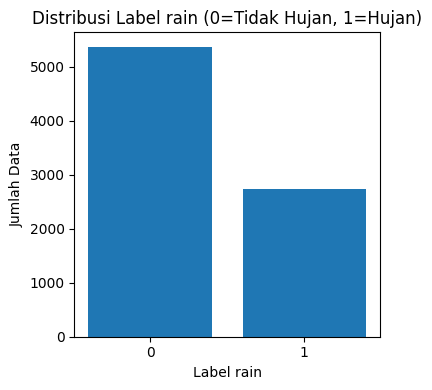

In [7]:
import matplotlib.pyplot as plt

label_counts = df['rain'].value_counts().sort_index()
plt.figure(figsize=(4,4))
plt.title('Distribusi Label rain (0=Tidak Hujan, 1=Hujan)')
plt.bar(label_counts.index.astype(str), label_counts.values)
plt.xlabel('Label rain')
plt.ylabel('Jumlah Data')
plt.tight_layout()
plt.show()


### 3.3.2 Distribusi Curah Hujan berdasarkan Label

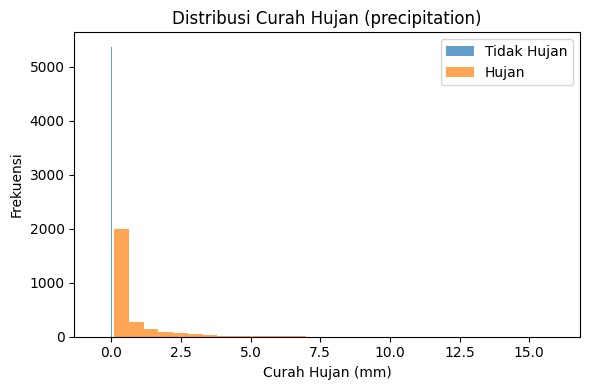

In [8]:
plt.figure(figsize=(6,4))
plt.title('Distribusi Curah Hujan (precipitation)')
plt.hist(df[df['rain']==0]['precipitation'], bins=30, alpha=0.7, label='Tidak Hujan')
plt.hist(df[df['rain']==1]['precipitation'], bins=30, alpha=0.7, label='Hujan')
plt.xlabel('Curah Hujan (mm)')
plt.ylabel('Frekuensi')
plt.legend()
plt.tight_layout()
plt.show()


### 3.4 Penanganan Missing Values dan Outlier

In [9]:
feature_cols = [
    'temperature_2m',
    'relative_humidity_2m',
    'precipitation',
    'wind_speed_10m',
    'cloud_cover',
    'hour',
    'day_of_week',
    'month',
]

all_cols_for_model = feature_cols + ['rain']
df_model = df[all_cols_for_model].copy()

print("===== CEK MISSING VALUE (SEBELUM PEMBERSIHAN) =====")
print(df_model.isna().sum())
print()

df_before = df_model.copy()
numeric_cols = feature_cols

print("===== IMPUTASI MISSING VALUE MENGGUNAKAN MEDIAN =====")
for col in numeric_cols:
    median_val = df_model[col].median()
    missing_before = df_model[col].isna().sum()
    df_model[col] = df_model[col].fillna(median_val)
    missing_after = df_model[col].isna().sum()
    print(f"Kolom: {col}")
    print(f"  Missing sebelum: {missing_before}")
    print(f"  Missing sesudah: {missing_after}")
    print(f"  Median: {median_val}")
    print('-'*40)

label_missing_before = df_model['rain'].isna().sum()
df_model = df_model.dropna(subset=['rain'])
label_missing_after = df_model['rain'].isna().sum()

print("\n===== LABEL 'rain' =====")
print("Missing sebelum drop:", label_missing_before)
print("Missing sesudah drop:", label_missing_after)

for col in numeric_cols:
    Q1 = df_model[col].quantile(0.25)
    Q3 = df_model[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_model[col] = df_model[col].clip(lower, upper)

print("\n===== TOTAL MISSING SESUDAH PEMBERSIHAN =====")
print(df_model.isna().sum())
print("\nShape sebelum:", df_before.shape)
print("Shape sesudah:", df_model.shape)


===== CEK MISSING VALUE (SEBELUM PEMBERSIHAN) =====
temperature_2m          0
relative_humidity_2m    0
precipitation           0
wind_speed_10m          0
cloud_cover             0
hour                    0
day_of_week             0
month                   0
rain                    0
dtype: int64

===== IMPUTASI MISSING VALUE MENGGUNAKAN MEDIAN =====
Kolom: temperature_2m
  Missing sebelum: 0
  Missing sesudah: 0
  Median: 26.9
----------------------------------------
Kolom: relative_humidity_2m
  Missing sebelum: 0
  Missing sesudah: 0
  Median: 82.0
----------------------------------------
Kolom: precipitation
  Missing sebelum: 0
  Missing sesudah: 0
  Median: 0.0
----------------------------------------
Kolom: wind_speed_10m
  Missing sebelum: 0
  Missing sesudah: 0
  Median: 5.8
----------------------------------------
Kolom: cloud_cover
  Missing sebelum: 0
  Missing sesudah: 0
  Median: 99.0
----------------------------------------
Kolom: hour
  Missing sebelum: 0
  Missing ses

### 3.5 Korelasi Antar Fitur

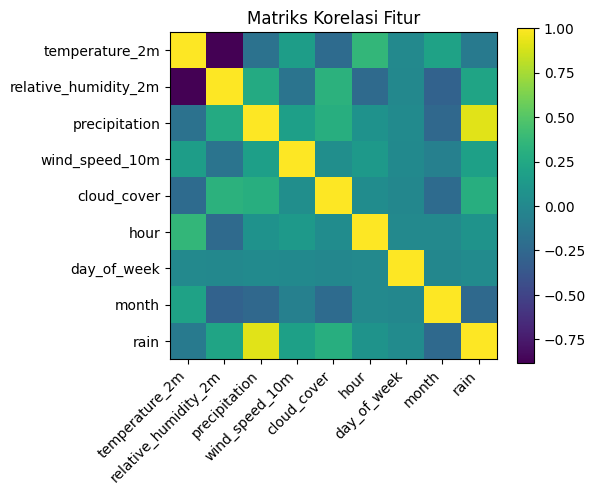

In [10]:
corr = df_model[feature_cols + ['rain']].corr()
plt.figure(figsize=(6,5))
plt.title('Matriks Korelasi Fitur')
plt.imshow(corr, interpolation='nearest')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.tight_layout()
plt.show()


## 4. Modeling: KNN, Gaussian Naive Bayes, Logistic Regression, Decision Tree, dan Random Forest

Pada tahap ini dilakukan pemodelan menggunakan lima algoritma supervised learning, yaitu:
- **K-Nearest Neighbors (KNN)**
- **Gaussian Naive Bayes**
- **Logistic Regression**
- **Decision Tree**
- **Random Forest**

Seluruh model dilatih menggunakan dataset yang sama sehingga hasilnya dapat dibandingkan secara adil. Evaluasi dilakukan dengan metrik:
- Accuracy
- Confusion Matrix
- Classification Report
- ROC Curve dan nilai AUC.


In [ ]:
X = df_model[feature_cols]
y = df_model['rain']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Jumlah data train:", X_train.shape[0])
print("Jumlah data test :", X_test.shape[0])


Jumlah data train: 6489
Jumlah data test : 1623


### 4.2 Definisi Lima Model

Pada bagian ini didefinisikan lima model klasifikasi yang akan dibandingkan, masing-masing dibungkus dalam `Pipeline` dengan `StandardScaler` (kecuali untuk Decision Tree dan Random Forest yang tidak wajib scaling).

In [ ]:
models = {}

# KNN 
models['KNN'] = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier())
])

# Gaussian Naive Bayes
models['GaussianNB'] = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', GaussianNB())
])

# Logistic Regression
models['LogisticRegression'] = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

# Decision Tree 
models['DecisionTree'] = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

# Random Forest
models['RandomForest'] = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

list(models.keys())


['KNN', 'GaussianNB', 'LogisticRegression', 'DecisionTree', 'RandomForest']

### 4.3 Pelatihan dan Evaluasi Awal Semua Model

Setiap model dilatih menggunakan data train dan dievaluasi pada data test dengan metrik **accuracy**, **classification report**, dan **confusion matrix**.

In [ ]:
results = {}

for name, pipe in models.items():
    print("="*60)
    print(f"Model: {name}")
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    # Simpan hasil dasar
    results[name] = {
        'model': pipe,
        'y_pred': y_pred,
        'accuracy': acc,
    }


Model: KNN
Accuracy: 0.9926

Classification Report:
              precision    recall  f1-score   support

           0     0.9899    0.9991    0.9944      1074
           1     0.9981    0.9800    0.9890       549

    accuracy                         0.9926      1623
   macro avg     0.9940    0.9895    0.9917      1623
weighted avg     0.9927    0.9926    0.9926      1623

Confusion Matrix:
[[1073    1]
 [  11  538]]
Model: GaussianNB
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      1074
           1     1.0000    1.0000    1.0000       549

    accuracy                         1.0000      1623
   macro avg     1.0000    1.0000    1.0000      1623
weighted avg     1.0000    1.0000    1.0000      1623

Confusion Matrix:
[[1074    0]
 [   0  549]]
Model: LogisticRegression
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0     1.0000

### 4.4 ROC Curve dan AUC

Untuk masing-masing model, dihitung juga ROC Curve dan nilai AUC guna melihat kemampuan model dalam membedakan kelas hujan dan tidak hujan.

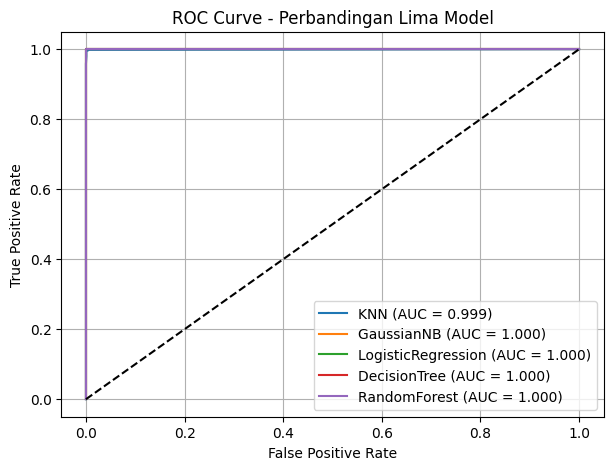

In [ ]:

plt.figure(figsize=(7, 5))

for name, info in results.items():
    model = info['model']
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
    
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_val = auc(fpr, tpr)
    info['fpr'] = fpr
    info['tpr'] = tpr
    info['auc'] = auc_val
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Perbandingan Lima Model")
plt.legend()
plt.grid(True)
plt.show()


### 4.5 Pemilihan Model Terbaik

Model terbaik dipilih berdasarkan kombinasi **accuracy** dan **AUC** tertinggi pada data test.

In [ ]:
best_name = None
best_score = -1

for name, info in results.items():
    score = info['auc'] * 0.7 + info['accuracy'] * 0.3
    if score > best_score:
        best_score = score
        best_name = name

best_model = results[best_name]['model']

print("Model terbaik berdasarkan kombinasi AUC & Accuracy:")
print(f"- Nama  : {best_name}")
print(f"- AUC   : {results[best_name]['auc']:.4f}")
print(f"- Acc   : {results[best_name]['accuracy']:.4f}")


Model terbaik berdasarkan kombinasi AUC & Accuracy:
- Nama  : GaussianNB
- AUC   : 1.0000
- Acc   : 1.0000


## 5. Deployment (Gradio dengan Model Terbaik)

Pada tahap ini, model terbaik disimpan dan digunakan dalam antarmuka Gradio sehingga pengguna dapat mengisi fitur cuaca dan memperoleh prediksi **Hujan** atau **Tidak Hujan**.

In [16]:
MODEL_PATH = 'weather_best_model_multi_alg.pkl'
joblib.dump(best_model, MODEL_PATH)
print(f"Model terbaik ({best_name}) disimpan ke: {MODEL_PATH}")

def predict_rain(temp, rh, prec, wind, cloud, hour, day_of_week, month):
    data = np.array([[temp, rh, prec, wind, cloud, hour, day_of_week, month]])
    proba = best_model.predict_proba(data)[0][1]
    label = 'Hujan' if proba >= 0.5 else 'Tidak Hujan'
    return f"{label} (Probabilitas hujan: {proba*100:.2f}%)"

with gr.Blocks() as demo:
    gr.Markdown('# Prediksi Hujan - Open-Meteo Makassar 2025 (Multi-Model)')
    gr.Markdown('Model terbaik dipilih dari: KNN, GaussianNB, Logistic Regression, Decision Tree, dan Random Forest.')

    with gr.Row():
        temp = gr.Number(label='Suhu (temperature_2m, °C)')
        rh = gr.Number(label='Kelembapan (relative_humidity_2m, %)')
        prec = gr.Number(label='Curah Hujan (precipitation, mm)')
        wind = gr.Number(label='Kecepatan Angin (wind_speed_10m)')
        cloud = gr.Number(label='Cloud Cover (%)')

    with gr.Row():
        hour_in = gr.Slider(0, 23, step=1, label='Jam (0-23)')
        dow_in = gr.Slider(0, 6, step=1, label='Day of Week (0=Senin ... 6=Minggu)')
        month_in = gr.Slider(1, 12, step=1, label='Bulan (1-12)')

    btn = gr.Button('Prediksi')
    output = gr.Textbox(label='Hasil Prediksi')

    btn.click(
        fn=predict_rain,
        inputs=[temp, rh, prec, wind, cloud, hour_in, dow_in, month_in],
        outputs=output
    )

demo.launch()


Model terbaik (GaussianNB) disimpan ke: weather_best_model_multi_alg.pkl
* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


e:\UNIVERSITAS MUHAMMADIYAH MAKASSAR\SEMESTER 5\APPLIED MACHINE LEARNING\TUGAS MID BESAR\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
